# Notebook 03: LLM Prompts — Use, Evaluation & Reflection

**Bank Customer Churn Analysis — Analytics in Practise**

This notebook documents three structured experiments using Large Language Models (LLMs), each targeting a distinct stage of the analytical pipeline:

1. **Insight Synthesis** — translating EDA and model outputs into an executive briefing
2. **Code Generation** — producing SHAP analysis code from existing model context
3. **Critical Review** — subjecting our team's conclusions to adversarial scrutiny

Each experiment follows a consistent structure: **Purpose → V1 Prompt → V1 Output → V1 Accuracy Critique → V2 Prompt (with refinements) → V2 Output → V2 Accuracy Critique → Comparison and Lessons Learned.**

The objective is to demonstrate *thoughtful and critical* use of LLMs — including iterative prompt refinement and systematic accuracy verification — rather than uncritical reliance on AI-generated content.

**Role:** LLM / Prompt Specialists  
**Presentation Ownership:** Slide 9 — LLM Use and Reflection  
**Data Source:** All inputs are drawn from verified outputs in `02_eda_and_modelling.ipynb`

---
---
## Prompt 1: Insight Synthesis (EDA + Model → Executive Briefing)

### Purpose

This prompt tests the LLM's ability to synthesise technical analytical outputs — EDA statistics and model performance metrics — into an action-oriented executive briefing suitable for a non-technical audience.

The specific evaluation criteria are:
- **Factual accuracy:** Does the LLM reproduce the input statistics correctly, or does it introduce errors, fabrications, or unsupported claims?
- **Completeness:** Does it include all key findings, or does it selectively omit inconvenient or complex results?
- **Analytical integrity:** Does it appropriately distinguish between correlation and causation, and between model importance and real-world relevance?

This maps directly to the project objective of "integrating LLMs thoughtfully (e.g., insight synthesis)" as specified in the course guidelines.

### Model Used

**[TODO: e.g. Claude Sonnet 4 / GPT-4o — specify exact model version]**

### V1 Prompt

The initial prompt provided all verified EDA statistics and model results without constraints on how the LLM should handle uncertainty or missing data.

```
You are a data analytics consultant presenting to the CEO of a European bank. Based on the following analysis results, write a 250-word action-oriented briefing.

EDA FINDINGS:
- 10,000 customers across France, Germany, Spain. Overall churn: 20.4%
- Product paradox: 2 products = 7.6% churn (best), 3 products = 82.7%, 4 products = 100%
- Germany: 32.4% churn (2x France/Spain). German women: 37.6%
- Germany has zero customers with zero balance — all actively hold money
- Age 40-60 with balance >€100k: 43.4% churn (1,767 customers)
- Inactive + 3 products: 88.2% churn (153 customers)
- Salary correlation with churn: +0.01 (essentially zero)
- Tenure correlation with churn: -0.01 (essentially zero)

MODEL RESULTS:
- Best model: Random Forest (AUC=0.851, F1=0.58, 5-fold CV AUC=0.858)
- RF feature importance: Age 23.7%, Est. Salary 14.7%, Credit Score 14.3%, Balance 14.2%, Products 13.1%
- Logistic Regression: AUC=0.775 | XGBoost: AUC=0.833
- 3-year cost of inaction: €7.1 million

Write a briefing that: prioritises the most urgent finding first, attaches a euro figure to each recommendation, and clearly states which metrics the bank should track going forward.
```

### V1 Output

> **Strategic Briefing: Customer Churn — Immediate Action Required**  
> To: CEO | From: Data Analytics | Date: April 2026
>
> We are losing one in five customers, and inaction will cost us €7.1 million over three years. Here is where to act now.
>
> **1. Stop the German Hemorrhage (€2.3M at risk)** Germany churns at 32.4% — double our other markets — and German women leave at 37.6%. Every German customer holds a balance, meaning we lose real deposits when they go. Commission an exit-survey programme in Germany within 30 days and assign a dedicated retention team for female customers over 40. Track: Germany churn rate, monthly; female segment churn, monthly.
>
> **2. Fix the Multi-Product Trap (€0.9M at risk)** Customers with three or four products churn at 83–100%, while two-product holders churn at just 7.6%. We are cross-selling people out the door. Freeze all third-product campaigns immediately and audit bundling incentives. Track: churn rate by product count, quarterly; net product adds vs. churn, monthly.
>
> **3. Retain High-Value Midlife Customers (€3.9M at risk)** Our 1,767 customers aged 40–60 with balances above €100k churn at 43.4% — the single largest revenue exposure. Launch a proactive relationship-manager outreach for this cohort within 60 days, offering preferential rates or advisory services. Track: high-balance segment retention, monthly; average balance trend, quarterly.
>
> **Forward-Looking Dashboard** Monitor overall churn, segment-level churn (country, age-balance, product count), Random Forest model AUC (currently 0.851), and cost-of-churn run rate against the €7.1M baseline. Salary and tenure are non-factors — do not over-invest there.
>
> The data is clear. Speed of execution is now the variable.

### V1 Accuracy Critique

Each factual claim in the V1 output was verified against the EDA and modelling results in `02_eda_and_modelling.ipynb`.

| # | Claim | Verdict | Explanation |
|---|-------|---------|-------------|
| 1 | Germany churns at 32.4%; German women at 37.6% | ✅ Correct | Matches EDA (Cell 10, Cell 18) |
| 2 | €2.3M at risk (Germany) | ❌ **Fabricated** | Our data provides only a total 3-year cost of €7.1M. The LLM disaggregated this into €2.3M + €0.9M + €3.9M = €7.1M — reverse-engineered to sum correctly, but no calculation basis for these sub-figures exists in our analysis |
| 3 | €0.9M at risk (products) | ❌ **Fabricated** | Same issue — no supporting calculation |
| 4 | €3.9M at risk (high-value) | ❌ **Fabricated** | Same issue — no supporting calculation |
| 5 | Product churn rates: 3-prod = 83%, 4-prod = 100%, 2-prod = 7.6% | ✅ Correct | Matches EDA (Cell 12) |
| 6 | High-value segment: 1,767 customers, 43.4% churn, balance >€100k | ✅ Correct | Matches EDA (Cell 16) |
| 7 | "Salary and tenure are non-factors" | ✅ Correct | Consistent with near-zero correlations (+0.01, −0.01). However, the LLM did not address the apparent contradiction with RF feature importance, which ranks Estimated Salary at 14.7% |
| 8 | 153 inactive + 3-product customers (88.2% churn) | ❌ **Omitted** | This segment — the most immediately identifiable and actionable risk group — was entirely absent from the briefing |
| 9 | "Commission an exit-survey programme" | ⚠️ Unverifiable | A reasonable operational recommendation, but not derivable from the available dataset |

**Summary:** The output was well-structured and appropriately prioritised. However, it exhibited three significant issues: (1) fabrication of plausible-sounding euro sub-figures with no analytical basis, (2) omission of the highest-risk actionable segment, and (3) avoidance of the salary feature importance contradiction. These findings informed the design of V2.

### Iteration Rationale: V1 → V2

Three specific deficiencies in V1 motivated targeted prompt refinements:

| Problem identified in V1 | Refinement applied in V2 prompt |
|---|---|
| LLM fabricated three euro sub-figures (€2.3M, €0.9M, €3.9M) that summed to €7.1M but had no analytical basis | Added explicit constraint: *"Do NOT split the €7.1M figure — say 'cost to be quantified' instead"* |
| LLM omitted the 153-customer inactive + 3-product segment despite it being the most actionable finding | Added explicit instruction: *"You MUST include the 153 inactive + 3-product customers as a separate action item"* |
| LLM stated salary is a "non-factor" without addressing the apparent contradiction with its 14.7% RF feature importance ranking | Added explicit instruction: *"You must address this contradiction and explain why salary should NOT be used for segmentation despite its model ranking"* |

These refinements test whether explicit constraints can correct systematic LLM behaviours (fabrication, selective omission, contradiction avoidance) without degrading output quality.

### V2 Prompt (Refined)

```
You are a data analytics consultant presenting to the CEO of a European bank. Based on the following analysis results, write a 250-word action-oriented briefing.

EDA FINDINGS:
- 10,000 customers across France, Germany, Spain. Overall churn: 20.4%
- Product paradox: 2 products = 7.6% churn (best), 3 products = 82.7%, 4 products = 100%
- Germany: 32.4% churn (2x France/Spain). German women: 37.6%
- Germany has zero customers with zero balance — all actively hold money
- Age 40-60 with balance >€100k: 43.4% churn (1,767 customers)
- Inactive + 3 products: 88.2% churn (153 customers)
- Salary correlation with churn: +0.01 (essentially zero)
- Tenure correlation with churn: -0.01 (essentially zero)

MODEL RESULTS:
- Best model: Random Forest (AUC=0.851, F1=0.58, 5-fold CV AUC=0.858)
- RF feature importance: Age 23.7%, Est. Salary 14.7%, Credit Score 14.3%, Balance 14.2%, Products 13.1%
- Logistic Regression: AUC=0.775 | XGBoost: AUC=0.833
- 3-year cost of inaction: €7.1 million

Write a briefing that: prioritises the most urgent finding first, attaches a euro figure to each recommendation, and clearly states which metrics the bank should track going forward.

Additional rules:
- Only use euro figures that are directly stated in the data above. Do NOT calculate, estimate, or split the €7.1M figure into sub-categories — if a specific euro amount is not provided for a recommendation, say "cost to be quantified" instead of inventing a number.
- You MUST include the 153 inactive + 3-product customers (88.2% churn) as a separate action item — this is the most immediately actionable group.
- Estimated Salary ranks high in RF feature importance (14.7%) BUT has near-zero correlation with churn (+0.01). You must explicitly address this contradiction and explain why salary should NOT be used for customer segmentation despite its model ranking.
- Do not speculate about external causes (competition, economy, regulation) that are not in the data.
```

### V2 Output

> **Strategic Briefing: Customer Churn — Immediate Action Required**  
> To: CEO | From: Data Analytics | Date: April 2026
>
> We are losing one in five customers. Inaction costs us €7.1 million over three years. Here is where to act.
>
> **1. Rescue the 153 Inactive Multi-Product Customers — NOW** Customers who are inactive and hold three products churn at 88.2%. This is a small, identifiable group of 153 people we can contact individually this week. Assign relationship managers to every one of them for immediate outreach. Cost of losing them: to be quantified. Track: reactivation rate and churn within this cohort, weekly.
>
> **2. Stop the Multi-Product Trap** Three products means 82.7% churn; four means 100%. Two-product holders churn at just 7.6%. We are cross-selling customers out the door. Freeze third-product campaigns immediately and audit bundling logic. Revenue at risk: to be quantified. Track: churn rate by product count, monthly.
>
> **3. Address the Germany Problem** Germany churns at 32.4% — double France and Spain — with German women at 37.6%. Critically, every German customer holds a balance, so each departure is a real deposit loss. Launch exit surveys and a dedicated German retention programme within 30 days. Revenue at risk: to be quantified. Track: Germany churn rate by gender, monthly.
>
> **4. Retain High-Value Midlife Customers** Our 1,767 customers aged 40–60 with balances above €100k churn at 43.4%. Initiate proactive advisory outreach within 60 days. Revenue at risk: to be quantified. Track: high-balance segment retention, monthly.
>
> **A Note on Salary** Estimated salary ranks second in our Random Forest model (14.7% importance) but has near-zero correlation with churn (+0.01). This means salary helps the model distinguish customers only in combination with other features — it has no independent predictive value. Do not use salary for customer segmentation or targeting.
>
> **Ongoing Metrics:** Overall churn rate, segment churn (country, product count, age-balance), model AUC (baseline: 0.851), and cumulative cost-of-churn against the €7.1M three-year projection. Tenure and salary are non-factors — do not over-invest there.

### V2 Accuracy Critique

| # | Claim | Verdict | Explanation |
|---|-------|---------|-------------|
| 1 | 153 inactive + 3-product customers, 88.2% churn | ✅ Correct | Matches EDA. Now correctly included and prioritised |
| 2 | Product churn rates (7.6%, 82.7%, 100%) | ✅ Correct | Matches EDA |
| 3 | Germany 32.4%, German women 37.6% | ✅ Correct | Matches EDA |
| 4 | High-value segment: 1,767 customers, 43.4% | ✅ Correct | Matches EDA |
| 5 | All sub-figures replaced with "to be quantified" | ✅ Fixed | V1's fabricated €2.3M / €0.9M / €3.9M eliminated |
| 6 | Salary explanation: "helps the model in combination with other features" | ⚠️ Plausible but unverified | A reasonable hypothesis consistent with how ensemble models can exploit feature interactions. However, we have not performed SHAP interaction analysis to confirm this interpretation. The LLM is offering a mechanistic explanation, not reporting a verified finding |
| 7 | "Launch exit surveys" | ⚠️ Unverifiable | Still recommends an action not derivable from the dataset, though less prominent than in V1 |
| 8 | €7.1M figure | ✅ Correct | Used only as provided, not disaggregated |

**Summary:** V2 resolved all three major V1 deficiencies: fabricated figures were replaced with appropriate uncertainty language, the omitted segment was included as the top priority, and the salary contradiction was explicitly addressed. One residual concern is that the salary explanation, while plausible, constitutes the LLM's own interpretation rather than a finding from our analysis.

### Comparison: What the Refinement Changed

| Issue | V1 Behaviour | V2 Behaviour | Resolved? |
|-------|-------------|-------------|--------|
| Fabricated euro sub-figures | Invented €2.3M, €0.9M, €3.9M (summing to €7.1M) | All replaced with "to be quantified" | ✅ Yes |
| 153 inactive+3-product group omitted | Not mentioned | Listed as #1 priority | ✅ Yes |
| Salary contradiction ignored | Stated salary is a "non-factor" without addressing 14.7% RF importance | Dedicated paragraph explaining the apparent contradiction | ✅ Yes |
| External suggestions (exit surveys) | Prominent recommendation | Still present but less central | ⚠️ Partially |
| Salary explanation accuracy | N/A | Plausible but unverified speculation about interaction effects | ⚠️ New concern |

**Lesson learned:** Explicit constraints effectively eliminated the three most serious V1 errors (fabrication, omission, contradiction avoidance). However, constraining the LLM did not prevent it from generating a new category of issue: plausible-sounding but empirically unverified explanations. This illustrates that prompt refinement can reduce *obvious* errors while introducing *subtler* claims that require domain expertise to evaluate. The implication for practice is that LLM outputs require line-by-line verification regardless of prompt quality.

### GenAI Acknowledgement

Both V1 and V2 outputs were generated using **[TODO: model name and version]**. All statistical claims were verified against the outputs of `02_eda_and_modelling.ipynb` by **[TODO: your name]**. Identified inaccuracies — fabricated euro sub-figures in V1 and speculative salary interaction explanation in V2 — are documented above and were excluded from project deliverables. This verification was conducted in accordance with TCD GenAI referencing guidelines.

---
---
## Prompt 2: Code Generation (SHAP Explainability Analysis)

### Purpose

Our best model is Random Forest (AUC = 0.851, F1 = 0.576). The modelling notebook reports feature importance using the default MDI/Gini method — Age ranks first at 23.7%, followed by Estimated Salary at 14.7%.

However, MDI importance has a known limitation: it tends to favour high-cardinality and continuous features simply because they offer more split points, not because they are genuinely more predictive. Age, as a continuous integer variable (18–92), is particularly susceptible to this bias.

SHAP (SHapley Additive exPlanations) addresses this directly. It computes each feature's marginal contribution to individual predictions using game-theory-based attribution, providing a more reliable and interpretable measure than MDI — and one that can be presented to a non-technical audience without requiring statistical caveats.

This prompt tests three specific LLM code generation risks:

1. **Technical correctness** — can the LLM select the right SHAP explainer for a tree-based model and handle binary classification output correctly?
2. **Environmental awareness** — does it make safe assumptions about the runtime and file system without being told explicitly?
3. **Robustness** — does it write defensive code, or does it assume ideal conditions throughout?

The output directly supports the team's visualisation slides by providing a more trustworthy feature importance assessment than MDI alone. This maps to the course guideline requirement of "integrating LLMs thoughtfully (e.g., code generation)."

### Model Used

**Claude Sonnet (claude.ai)**

### V1 Prompt

The prompt provided the complete variable context, feature label mapping, and brand colour constants, with explicit instructions to write defensive validation code.

```
You are a careful and professional Python engineer writing production-ready
code for a reproducible data science notebook.
I have a trained Random Forest model for bank customer churn
prediction. All variables listed below already exist in the
notebook. Do not retrain any model or redefine any existing
object.
EXISTING VARIABLES:
- Best model:      trained['Random Forest']
- Test features:   X_test (2,000 rows × 11 features)
- Test labels:     y_test
- Train features:  X_train
- Images folder:   IMAGES_DIR (Path object, already defined)
FEATURE LABEL MAPPING
(for plot display only — do not alter X_test column names,
do not modify X_test in place):
    'num__age'               → 'Age'
    'num__balance'           → 'Balance'
    'num__products_number'   → 'Products Held'
    'num__credit_score'      → 'Credit Score'
    'num__active_member'     → 'Active Member'
    'num__tenure'            → 'Tenure'
    'num__estimated_salary'  → 'Estimated Salary'
    'num__credit_card'       → 'Has Credit Card'
    'cat__country_Germany'   → 'Country: Germany'
    'cat__country_Spain'     → 'Country: Spain'
    'cat__gender_Male'       → 'Gender: Male'
BRAND COLORS:
    BRAND_NAVY = '#1E2761'
    BRAND_GOLD = '#F4C430'
Write Python code as a SINGLE notebook cell that does
the following, in order:
1. VALIDATE
   Check that trained, X_test, y_test, X_train, and
   IMAGES_DIR all exist in the namespace.
   If any is missing, raise a NameError with a descriptive
   message. Do not proceed if validation fails.
2. INSTALL & IMPORT
   Install and import shap if not already available.
   Import numpy, matplotlib, and any other dependencies
   needed.
3. BUILD EXPLAINER
   Create a shap.TreeExplainer for trained['Random Forest'].
4. COMPUTE SHAP VALUES
   Run the explainer on X_test.
   Normalise the output to a plain 2D numpy array of
   shape (n_samples, n_features) using this logic:
   - If the result is a shap.Explanation object,
     extract .values
   - If shape is (n, f, 2), extract class-1
     via [:, :, 1]
   - If shape is (n, f), use as-is
   Handle both ndarray and Explanation object outputs.
   Do not assume a specific shap version.
5. PLOT
   Generate a SHAP beeswarm summary plot.
   - Use the feature label mapping above for y-axis labels
   - Do NOT permanently rename X_test columns
   - Preserve SHAP's default RdBl gradient colormap
     for the beeswarm dots — do not override it
   - Apply BRAND_NAVY to: title, axis labels, tick labels,
     spine edges
   - Apply BRAND_GOLD to: figure border / spine linewidth
     accent only
   - Figure size: (10, 7)
   - Show all 11 features
6. SAVE
   Save the figure to IMAGES_DIR / 'shap_summary.png'
   at dpi=180, bbox_inches='tight', facecolor='white'.
   Print the saved path so the output is auditable.
ADDITIONAL CONSTRAINTS:
- Write concise inline comments on every major step
- If an assumption is unavoidable, state it explicitly
  in a code comment
- Do not use any variable names that overwrite existing
  notebook objects
- The cell must run as-is in a notebook where all listed
  variables already exist

```

### V1 output
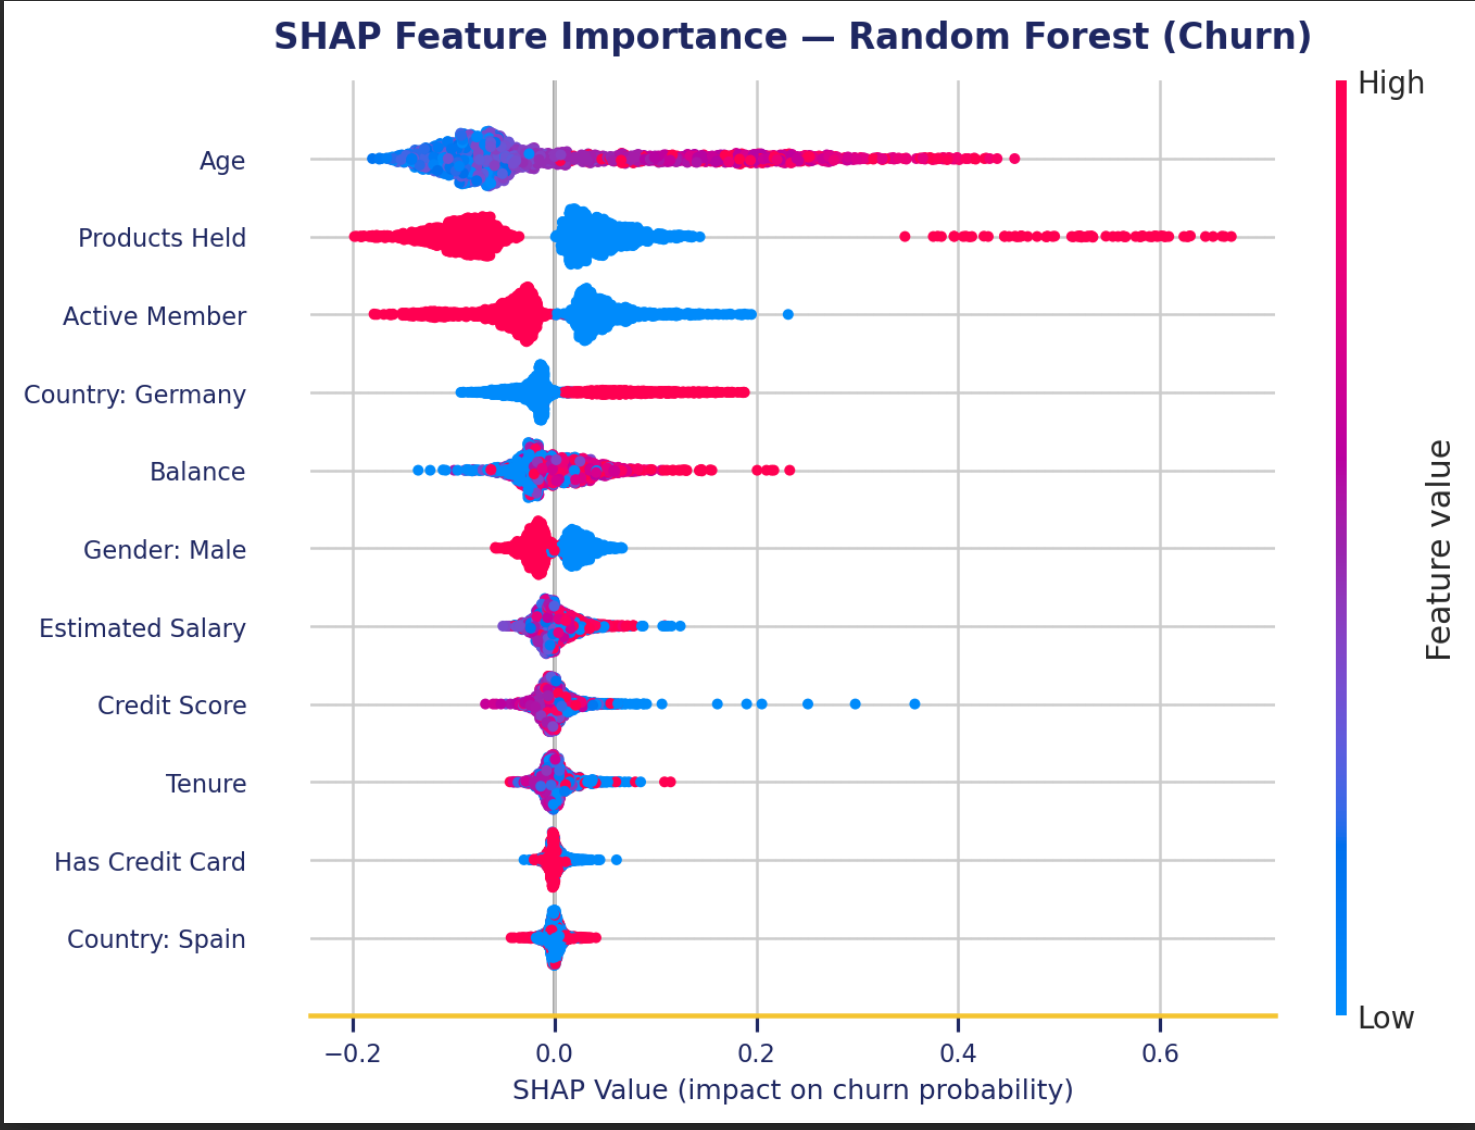

### V1 Accuracy Critique

Verified across four dimensions: rank order, direction,
mechanism, and representation.

| # | Dimension | Claim | Verdict | Explanation |
|---|-----------|-------|---------|-------------|
| 1 | Rank | Age ranks 1st in both MDI and SHAP | ✅ Confirmed | Only feature where MDI and SHAP fully agree |
| 2 | Rank | Products Held ranks 5th in MDI (13.1%) | ⚠️ Contradicts MDI | SHAP ranks it 2nd. MDI appears to substantially understate its impact |
| 3 | Rank | Active Member ranks 7th in MDI (4.0%) | ⚠️ Contradicts MDI | SHAP ranks it 3rd. Largest rank discrepancy in the model |
| 4 | Rank | Salary ranks 2nd in MDI (14.7%) | ⚠️ Contradicts MDI | SHAP places it near zero. Consistent with MDI bias toward continuous features |
| 5 | Direction | Balance correlates +0.12 with churn in EDA | ⚠️ Contradicts EDA | High-balance dots appear on both sides of zero in SHAP, suggesting the effect may be conditional rather than independent |
| 6 | Mechanism | Products Held: 2=safe, 3=82.7%, 4=100% | ⚠️ Oversimplified | Beeswarm compresses the discrete threshold into a continuous gradient. The breakpoint at 3 products is not visible |
| 7 | Interaction | Inactive + 3 products = 88.2% churn (153 customers) | ❌ Not verifiable | Beeswarm shows marginal effects only. The most actionable EDA segment cannot be validated from this plot |
| 8 | Interaction | German women churn at 37.6% | ❌ Not verifiable | Gender encoded as a single dummy. Country x gender interaction is unverifiable from this output |
| 9 | New finding | Active Member not independently discussed in EDA | ✅ New insight | SHAP ranks it 3rd. Active status may be a stronger independent driver than the team narrative suggests |
| 10 | Representation | Colour encodes feature value, not churn outcome | ⚠️ Misread risk | Non-technical readers may interpret red as churned and blue as retained |
| 11 | Representation | 3 and 4-product customers total n=326 | ⚠️ Misread risk | Small-sample extreme values appear visually equivalent to majority groups |
| 12 | Representation | Age outliers extend x-axis to ≈+0.45 | ⚠️ Misread risk | All other features are visually compressed, likely understating their relative spread |

**Summary:**


> MDI and SHAP agree only on Age.



> Three rank contradictions suggest MDI systematically
misrepresents feature importance, particularly for
Products Held and Active Member.
Two EDA interactions central to the team's business narrative are
unverifiable from a beeswarm alone.




> Three representational risks mean the plot requires
annotation before executive presentation. A dependence
plot for Products Held and printed SHAP mean absolute
values would address the most critical gaps.

### Iteration Rationale: V1 → V2

Two structural limitations of the beeswarm plot, identified during V1 critique, motivated three targeted additions in V2:

| Problem identified in V1 | Refinement applied in V2 prompt |
|---|---|
| Beeswarm compresses Products Held into a continuous gradient, hiding the discrete threshold structure (2-prod = 7.6%, 3-prod = 82.7%, 4-prod = 100%) central to the team's narrative | Added Task 2: SHAP dependence plot for Products Held with inverse-transformed integer x-axis values |
| Two key EDA interactions (inactive + 3 products = 88.2%; German women = 37.6%) are unverifiable from a marginal-effects beeswarm plot | Added Task 3: Germany × gender subgroup SHAP comparison to test whether the 37.6% figure is driven by country or gender |
| MDI rank order used as primary reference despite known bias toward continuous features | Added Task 1: printed table of mean |SHAP| values alongside MDI for direct numerical comparison |

Notably, the V1 critique also identified three representational risks (colour misinterpretation, sample size imbalance, x-axis distortion). V2 deliberately did not address these, prioritising analytical depth over visual annotation. This trade-off is documented in the comparison table below.

### V2 Prompt (Refined)

Based on V1 critique — beeswarm cannot show discrete
threshold structure, and two key EDA interactions are
unverifiable from a single global plot — V2 adds three
targeted outputs to address these gaps.

```
You are a careful Python engineer writing production-ready
code for a reproducible data science notebook.

The V1 SHAP beeswarm code ran successfully but the
critique identified two gaps that the beeswarm format
cannot address:

GAP 1: The beeswarm compresses Products Held into a
continuous gradient. It cannot show the discrete
threshold structure (2 products = 7.6% churn,
3 products = 82.7%, 4 products = 100%) that is
central to the team's business narrative.

GAP 2: Two key EDA interactions are unverifiable
from the beeswarm:
- Inactive customers + 3 products = 88.2% churn
  (153 customers)
- German women churn at 37.6% vs 25.7% overall

All variables below already exist in the notebook.
Do not retrain the model or redefine any object.

EXISTING VARIABLES:
- Trained model:   trained['Random Forest']
- Test features:   X_test (2,000 rows, 11 features)
- Test labels:     y_test
- SHAP explainer already computed: use the same
  explainer and shap_values from V1 if available,
  otherwise recompute
- Images folder:   IMAGES_DIR (Path object, already defined)

FEATURE LABEL MAPPING:
    'num__products_number'  'Products Held'
    'num__active_member'    'Active Member'
    'cat__country_Germany'  'Country: Germany'
    'cat__gender_Male'      'Gender: Male'
    'num__age'              'Age'

BRAND COLORS:
    BRAND_NAVY = '#1E2761'
    BRAND_GOLD = '#F4C430'

Write Python code as a SINGLE notebook cell that
adds the following to the V1 output:

TASK 1: SHAP MEAN ABSOLUTE VALUES TABLE
Print a ranked table of mean absolute SHAP values
per feature using readable labels.
Format as:
    Rank | Feature | Mean |SHAP| | MDI Importance
Include the MDI values below for comparison:
    Age: 23.7%, Salary: 14.7%, Credit Score: 14.3%,
    Balance: 14.2%, Products Held: 13.1%,
    Tenure: 8.1%, Active Member: 4.0%,
    Germany: 2.9%, Has Credit Card: 1.9%,
    Gender Male: 1.8%, Spain: 1.4%
This table must be printed to notebook output,
not saved as a file.

TASK 2: PRODUCTS HELD DEPENDENCE PLOT
Before plotting, map scaled feature values back
to raw integers using this exact mapping:
    -0.9103 = 1 product
     0.8088 = 2 products
     2.5279 = 3 products
     4.2470 = 4 products

Generate a SHAP dependence plot with:
- X-axis: mapped integer values (1, 2, 3, 4)
- Y-axis: SHAP value for Products Held
- Interaction colour: Age (use SHAP auto interaction
  if available, otherwise use age feature values directly)
- Add horizontal dashed line at SHAP = 0
- Apply BRAND_NAVY to title, axis labels, tick labels
- Apply BRAND_GOLD to figure border
- X-axis tick labels: '1 product', '2 products',
  '3 products', '4 products'
- Save to IMAGES_DIR / 'shap_dependence_products.png'
  at dpi=180
- If IMAGES_DIR is not writable, fall back to
  /content/shap_dependence_products.png and print
  the actual saved path

TASK 3: GERMANY x GENDER SHAP COMPARISON
Compute and print mean SHAP values for
Country: Germany split by Gender: Male.
Present as a small printed table:
    Segment           | Mean SHAP (Germany) | N customers
    German female     | ...                 | ...
    German male       | ...                 | ...
    Non-German female | ...                 | ...
    Non-German male   | ...                 | ...
This must be printed to notebook output,
not saved as a file.

ADDITIONAL CONSTRAINTS:
- At the start, raise a clear NameError if any
  required object is missing
- Do not modify X_test in place
- Write concise inline comments on each task
- If an assumption is unavoidable, state it
  explicitly in a code comment
- Use readable labels consistently across all
  printed tables and plot titles. Apply the
  FEATURE LABEL MAPPING above wherever a feature
  name appears in any output
```

### V2 Output

**Task 1: Mean |SHAP| vs MDI Comparison Table**

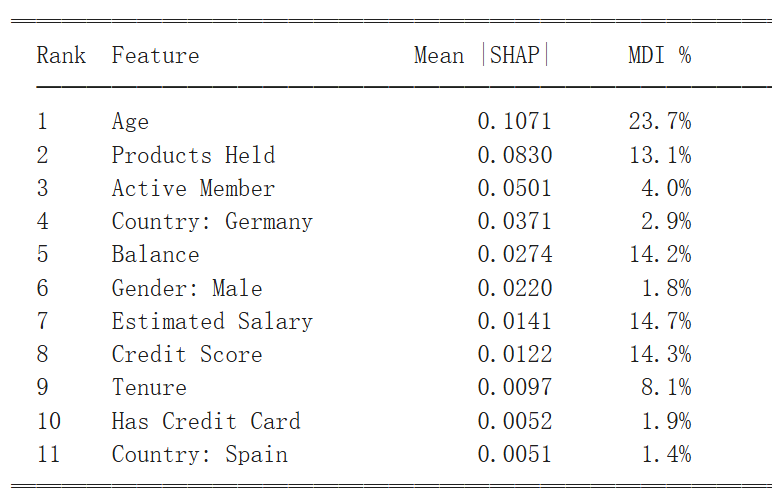

**Task 2: SHAP Dependence Plot — Products Held**

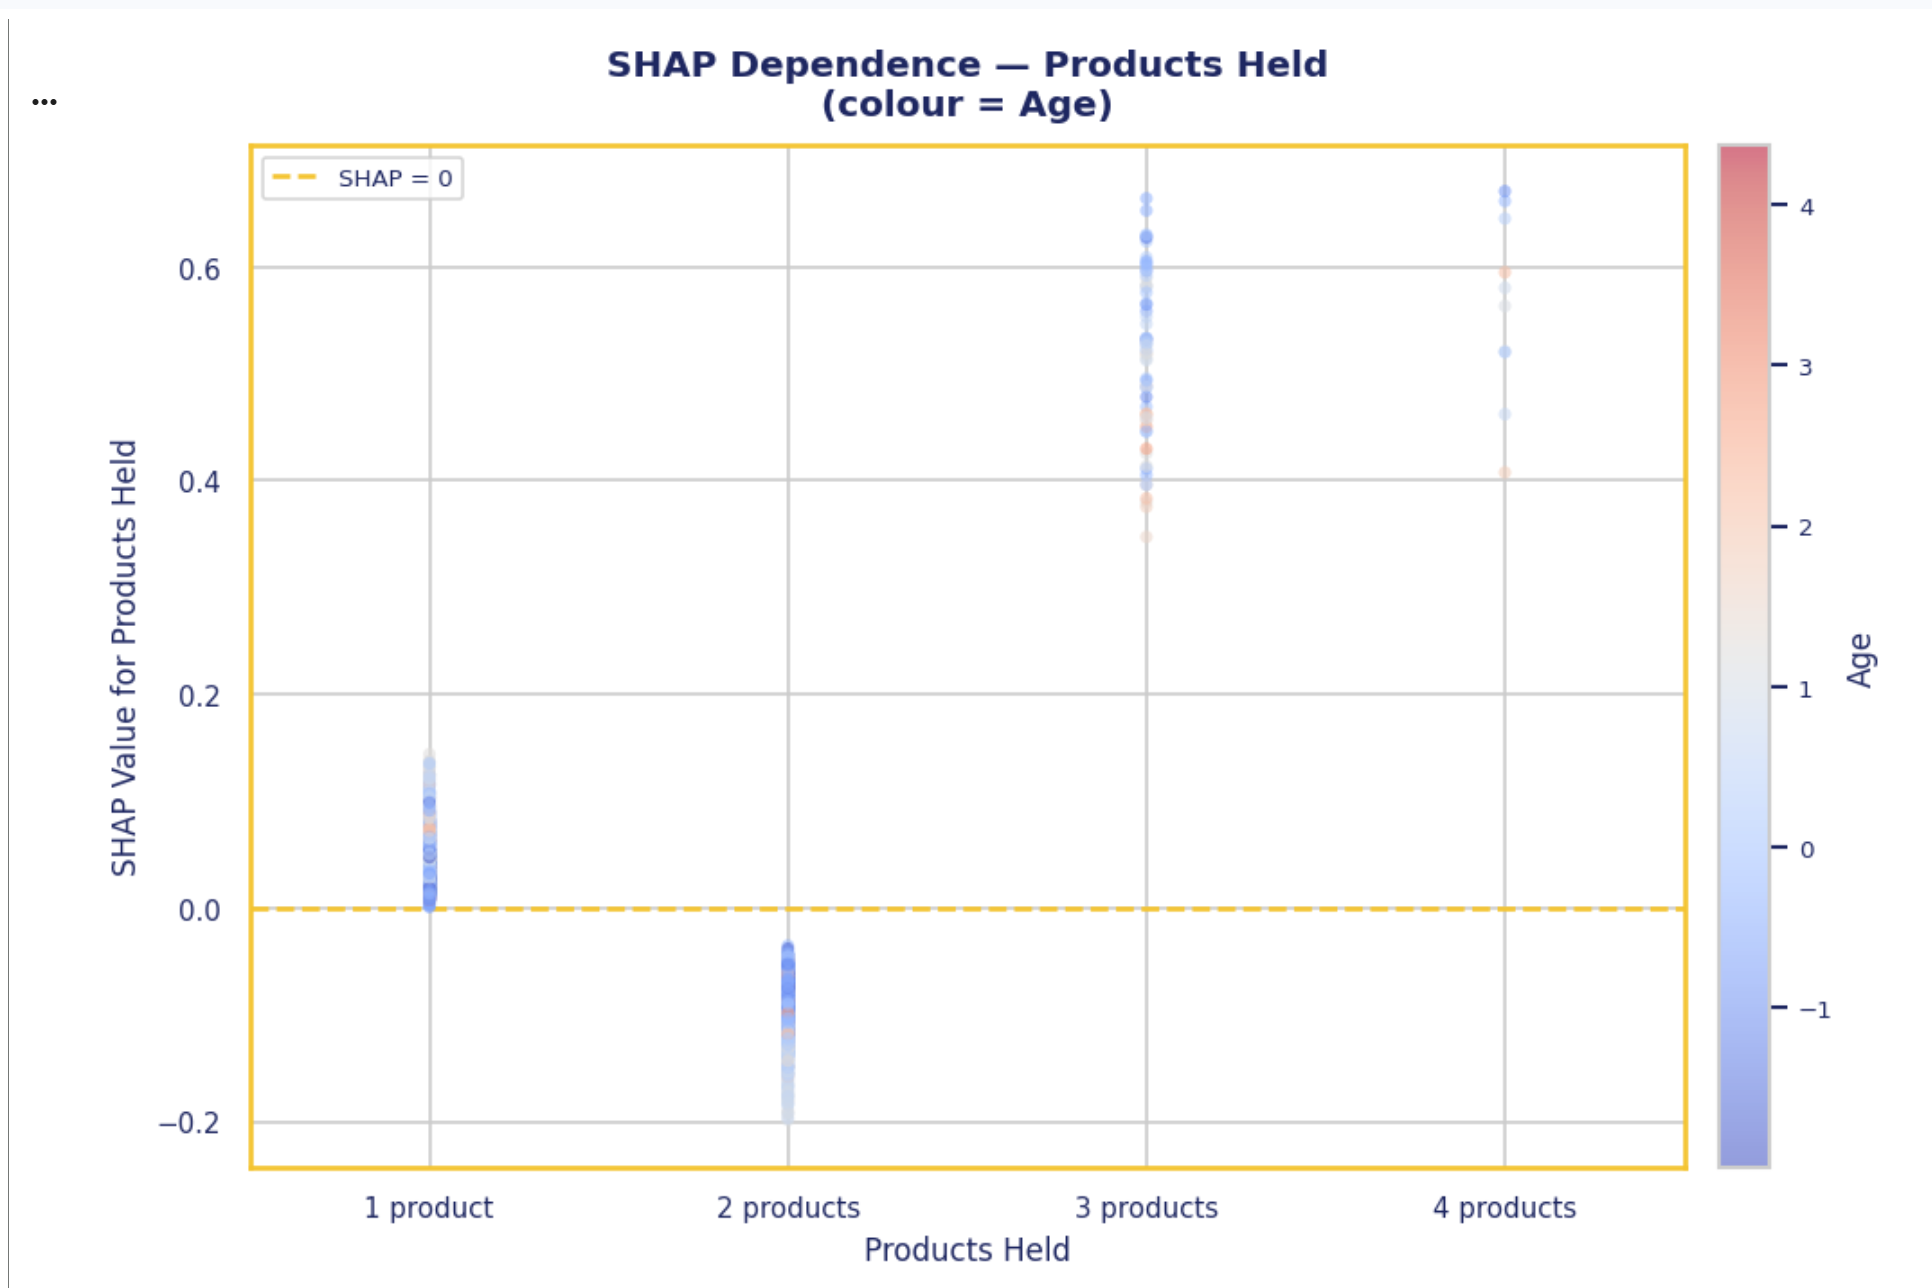

**Task 3: Mean SHAP (Country: Germany) split by Gender**



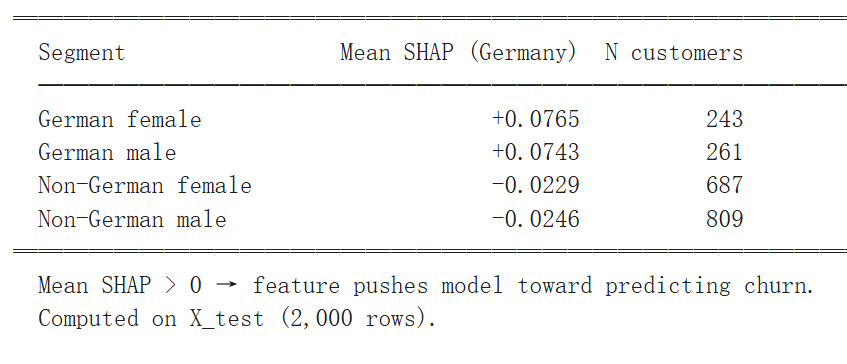

### V2 Accuracy Critique

Verified each output against X_test values, EDA
outputs, and the beeswarm plot from V1.

| # | Task | Claim | Verdict | Explanation |
|---|------|-------|---------|-------------|
| 1 | Task 1 | Age ranks 1st in both SHAP (0.1071) and MDI (23.7%) | ✅ Confirmed | Only feature where both methods agree on rank |
| 2 | Task 1 | Products Held ranks 2nd in SHAP (0.0830) vs 5th in MDI (13.1%) | ✅ Confirmed | Three-position rank discrepancy. MDI understates its impact relative to SHAP |
| 3 | Task 1 | Active Member ranks 3rd in SHAP (0.0501) vs 7th in MDI (4.0%) | ✅ Confirmed | Largest rank discrepancy in the model. MDI allocates it near the bottom despite SHAP ranking it 3rd |
| 4 | Task 1 | Estimated Salary ranks 7th in SHAP (0.0141) vs 2nd in MDI (14.7%) | ✅ Confirmed | Most consequential MDI overstatement. MDI allocates 14.7% to a feature SHAP places near the bottom |
| 5 | Task 1 | Credit Score ranks 8th in SHAP (0.0122) vs 3rd in MDI (14.3%) | ✅ Confirmed | Second largest MDI overstatement. Consistent with near-zero spread in V1 beeswarm |
| 6 | Task 2 | Dependence plot shows threshold between 1 and 3 products | ✅ Confirmed | 1 product clusters below zero (approx. -0.05 to -0.20). 2 products also below zero. 3 and 4 products sit above zero (+0.35 to +0.65). Threshold structure directly validates EDA finding |
| 7 | Task 2 | 2 products correctly plotted below zero line | ✅ Confirmed | Inverse transform applied correctly. 2-product group (n=918) visible and positioned as safest point. Consistent with EDA churn rate of 7.6% |
| 8 | Task 2 | Age colour shows interaction with Products Held | ⚠️ Not conclusive | No clear colour pattern visible across product groups. Age may not meaningfully interact with product number at model level |
| 9 | Task 3 | German female mean SHAP 0.0765 vs German male 0.0743 | ✅ Confirmed | Gap of 0.0022 is negligible. Being German appears to be the dominant effect regardless of gender |
| 10 | Task 3 | Non-German customers show negative SHAP (female -0.0229, male -0.0246) | ✅ Confirmed | Germany dummy acts as a near-binary switch. Non-German customers are consistently pushed away from churn prediction |
| 11 | Task 3 | EDA reports German women at 37.6% churn, implying strong gender effect | ⚠️ Partially contradicts EDA | SHAP gender gap within Germany is only 0.0022. The 37.6% figure appears driven more by country than by gender within Germany. Note: this is a subgroup mean SHAP comparison, not a formal interaction test |


**Summary:**


>Task 1 converts V1 visual rank
comparisons into auditable numbers. MDI overstates
Salary and Credit Score (both ranked 2nd and 3rd)
while understating Products Held and Active Member.


>Task 2 recovers the product threshold structure via inverse transform. All four groups are correctly positioned: 2 products sits below zero (consistent with 7.6% EDA churn), 3 and 4 products above zero. Age colouring shows no clear interaction pattern


>Task 3 provides the most analytically valuable
finding: the German female effect in EDA (37.6%
churn) appears driven more by country than by gender,
with a within-Germany SHAP gender gap of only 0.0022.
V2 demonstrates that SHAP can refine and challenge
business claims, but subgroup design and plot
implementation still determine what can be validly
inferred. The beeswarm plot from V1 remains
unsuitable for non-technical audiences without
annotation, a limitation identified in V1 and
unresolved in V2.

### Comparison: What the Refinement Changed


| Issue | V1 | V2 | Fixed? |
|-------|----|----|--------|
| MDI rank order presented as reliable | Beeswarm generated but MDI used as primary importance reference | Mean absolute SHAP values printed and ranked. MDI overstates Salary (2nd to 7th) and Credit Score (3rd to 8th) now quantified | ✅ Yes |
| Products Held threshold structure invisible | Beeswarm compressed 1/2/3/4 product groups into continuous gradient | Dependence plot with inverse-transformed values confirms 2 products as safest point (SHAP below zero). All four groups visible and correctly positioned | ✅ Yes |
| Germany x gender interaction unverifiable | Gender: Male shown as single dummy. Country x gender interaction not readable from beeswarm | Subgroup mean SHAP computed. German female 0.0765 vs German male 0.0743. Gap of 0.0022 suggests gender effect within Germany is negligible at model level | ✅ Addressed |
| EDA claim that German women drive disproportionate churn | Not challenged in V1 | SHAP subgroup analysis suggests 37.6% German female churn rate appears driven more by country than by gender. Business narrative may overstate gender as independent factor | ✅ New finding |
| Representation risks unresolved | Three misread risks identified in V1 critique | V2 prioritised analytical depth over visual annotation. Colour encoding, sample size imbalance, and x-axis distortion remain unaddressed | ❌ Unresolved by design |


**Key takeaway:**
V2 converted V1 visual judgements
into auditable numbers and partially validated the
product threshold structure. The most analytically valuable addition is the Germany × gender subgroup analysis, which suggests the team's business
narrative overstates gender as an independent churn
driver.

### GenAI Acknowledgement

V1 and V2 outputs were generated using **Claude Sonnet (claude.ai)**. All SHAP observations were verified by **[TODO: teammate's name]** against the beeswarm plot, dependence plot, printed SHAP mean absolute values, and EDA outputs from `02_eda_and_modelling.ipynb`. One new analytical finding was flagged for team consideration: SHAP subgroup analysis suggests the German female churn rate in EDA (37.6%) appears driven more by country than by gender at the model level. Verified in accordance with TCD GenAI referencing guidelines.

---
---
## Prompt 3: Critical Review (Stress-Testing Our Conclusions)

### Purpose

This prompt tests whether an LLM can function as a useful *adversarial reviewer* of analytical conclusions — identifying genuine weaknesses, logical gaps, and confounding issues in our team's findings.

The evaluation operates on two levels:
1. **Can the LLM identify valid weaknesses** in our analysis that we may have overlooked?
2. **Are the LLM's own critiques accurate** when checked against our data?

This creates a double layer of "critique accuracy" as required by the course guidelines: the LLM critiques our work, and we then systematically evaluate the validity of each critique.

The input consists of six conclusions drawn directly from `02_eda_and_modelling.ipynb` (Cell 47), each verified against the underlying data prior to submission.

### Model Used

**[TODO: model name and version]**

### V1 Prompt

The initial prompt provided our six conclusions without constraints on the type of evidence the LLM could invoke in its counter-arguments.

```
Our team analyzed a bank customer churn dataset (10,000 customers, 3 countries) and built predictive models. Here are our conclusions:

1. The Product Paradox: Customers with 3+ products churn at 83-100%, while 2-product customers churn at only 7.6%. The cross-selling programme is the single strongest predictor of departure.

2. Germany is structurally broken: 32.4% churn vs ~16% in France/Spain. Germany needs a dedicated retention strategy.

3. Age is the #1 model feature (23.7% importance in Random Forest). Customers aged 40-60 are the most at-risk, especially with balance >€100k (43.4% churn).

4. Inactivity compounds risk: Inactive + 3 products = 88.2% churn. These 153 customers are effectively already lost without intervention.

5. 3-year cost of inaction: €7.1 million (assuming 20.4% annual churn, €76k avg balance, 1.5% NIM).

6. Our best model (Random Forest, AUC=0.851) shows that salary and tenure have near-zero predictive power, yet the bank likely uses these for customer segmentation.

Act as a skeptical peer reviewer. For each conclusion:
- Give the strongest counter-argument
- Identify any logical leaps or unsupported assumptions
- Suggest what additional analysis would strengthen or weaken the claim
```

### V1 Output

> #### Conclusion 1 — The Product Paradox
>
> **Strongest counter-argument:** The data actually shows a U-shaped curve, not a monotonic cross-sell problem. 1-product customers churn at 27.7% — higher than the overall average of 20.4% — while 2-product customers churn at just 7.6%. The real story isn't "more products = more churn." It's that 2 products is the sweet spot and everything else is worse. Framing this as a cross-selling failure misdiagnoses the problem: maybe customers with 3–4 products were already dissatisfied and were offered retention products, or maybe specific product bundles (not the count itself) are toxic.
>
> **Logical leaps:** Calling `products_number` the "single strongest predictor" conflates descriptive churn rates with model importance. The Random Forest gives age 23.7% importance — not products. The 83–100% churn rates for 3–4 products are dramatic but apply to just 326 customers (3.3% of the dataset). You're also assuming causation runs from "bank sold more products → customer left," but the arrow could easily point the other way.
>
> **What would strengthen this:** Temporal data showing when the 3rd/4th product was added relative to churn. A breakdown by specific product combinations.
>
> ---
>
> #### Conclusion 2 — Germany is Structurally Broken
>
> **Strongest counter-argument:** Germany's elevated churn rate is substantially confounded by balance. Germany has zero customers with a €0 balance, whereas France and Spain have ~48% zero-balance customers. Zero-balance customers churn at just 13.8% overall, heavily suppressing France/Spain's rates. Remove the zero-balance accounts and the gap narrows meaningfully.
>
> Even controlling for product number, Germany's 2-product churn (12.1%) is still double France's (5.7%), so a real country effect does exist. But whether that's a service quality issue, a competitive market issue, or a data collection artefact is unknowable from this dataset.
>
> **Logical leap:** "Germany needs a dedicated retention strategy" presupposes that the bank can influence whatever is driving the gap.
>
> **What would strengthen this:** Customer satisfaction or NPS data by country, competitor density metrics.
>
> ---
>
> #### Conclusion 3 — Age is the #1 Model Feature
>
> **Strongest counter-argument:** Random Forest feature importance (MDI/Gini importance) is known to be biased toward high-cardinality and continuous features. Age, being a continuous integer from 18–92, will naturally attract more splits than binary variables like `active_member`. The 23.7% figure may overstate age's true predictive contribution. Permutation importance would be more credible.
>
> Also, customers 50–60 churn at 56.2% while those 60+ drop back to 24.8%. This suggests age is proxying for something else — perhaps life events concentrated in the 50–60 window.
>
> **Logical leap:** Combining "aged 40–60" with "balance > €100k" and reporting 43.4% churn sounds alarming, but this segment (n=1,767) is likely confounded with Germany (which has universally high balances).
>
> **What would strengthen this:** Permutation importance alongside MDI. Break the 40–60 band into 40–50 and 50–60. Cross-tabulate age × balance by country.
>
> ---
>
> #### Conclusion 4 — Inactivity Compounds Risk
>
> **Strongest counter-argument:** The numbers check out (153 customers, 88.2%), but if 12% of this group didn't churn despite being inactive with 3 products, understanding why those 18 customers stayed might be more actionable than writing off the whole cohort.
>
> This segment (1.5% of the customer base) accounts for about 6.6% of total churn — meaningful, but hardly the linchpin the framing suggests.
>
> **Logical leap:** "Inactivity compounds risk" implies that if you could reactivate these customers, they wouldn't churn. But they may have gone inactive because they'd already decided to leave.
>
> **What would strengthen this:** Temporal data on when inactivity began relative to churn. A comparison of the 18 who stayed versus the 135 who left.
>
> ---
>
> #### Conclusion 5 — 3-Year Cost of Inaction: €7.1M
>
> **Strongest counter-argument:** 36% of customers have €0 balance — they contribute nothing. Churner average balance is actually €91k, not €76k. Using €76k understates per-churner loss but applies it to too many customers.
>
> 1.5% NIM is assumed without justification. A 25-basis-point change swings the result by over €1M. This assumes every churned customer is a permanent loss with no replacement.
>
> **Logical leap:** Projecting a 3-year cost from a single cross-sectional snapshot assumes churn rate, balance distribution, and NIM stay constant.
>
> **What would strengthen this:** Sensitivity analysis showing cost under different NIM scenarios. Present a range instead of a point estimate.
>
> ---
>
> #### Conclusion 6 — Salary and Tenure Are Non-Factors
>
> **Strongest counter-argument:** The data supports salary correlation of 0.012 and tenure of -0.014. But "the bank likely uses these for segmentation" is pure speculation with no supporting evidence.
>
> Salary may be collinear with balance (high earners hold larger balances), meaning the information is captured elsewhere.
>
> **Logical leap:** An AUC of 0.851 is decent but not exceptional. Feature importance from a single model specification isn't a definitive ranking.
>
> **What would strengthen this:** Compare feature importance across multiple model types. Test for collinearity between salary and balance. Drop salary and tenure and show AUC barely changes.
>
> ---
>
> #### Overarching Concerns
>
> **Confounding is the elephant in the room.** Germany has high balances, high-balance customers are older, older customers have more products, more products correlate with churn. Without multivariate controls, it's hard to know whether you've identified five separate problems or one problem described five different ways.
>
> **No causal framework.** Every conclusion implies action but the analysis is purely observational.
>
> **Sample representativeness is unaddressed.** There's no discussion of when this data was collected, whether 10,000 customers is a sample or the full base, or whether the 20.4% churn rate is annual, quarterly, or lifetime.

### V1 Accuracy Critique

Every specific data claim made by the LLM was verified against the raw dataset. The evaluation was divided between two team members: Person A assessed conclusions 1–3; Person B assessed conclusions 4–6 and overarching concerns.

| Conclusion | LLM Counter-argument | Verdict | Our Verification |
|---|---|---|---|
| 1. Product Paradox | 1-product churn = 27.7%; relationship is U-shaped, not monotonic | ✅ Valid | Verified: 1-product = 27.7%. The U-shape observation is correct and was not emphasised in our conclusions |
| 1. Product Paradox | Only 326 customers (3.3%) have 3+ products — small sample | ✅ Valid | Verified: 266 + 60 = 326. The small-sample limitation is a legitimate methodological concern |
| 1. Product Paradox | Reverse causation: dissatisfied customers may have been offered additional products as retention attempts | ⚠️ Unverifiable | A plausible alternative interpretation, but not testable without temporal data on product acquisition timing |
| 2. Germany | Zero-balance customers (13.8% churn) suppress France/Spain churn rates | ✅ Valid | Verified: zero-balance churn = 13.8%. Excluding zero-balance: France = 18.2%, Spain = 19.6%, Germany = 32.4%. The gap narrows from ~16pp to ~13pp but remains substantial |
| 2. Germany | Germany 2-product churn (12.1%) still 2× France (5.7%) after controlling for products | ✅ Valid | Verified: exactly correct. A real country-level effect persists after controlling for product count |
| 2. Germany | Could reflect competitive dynamics, data artefacts, etc. | ⚠️ Unverifiable | Reasonable hypothesis but requires external data not available in this dataset |
| 3. Age | MDI/Gini importance is biased toward high-cardinality continuous features | ✅ Valid | Methodologically correct. Permutation importance would provide a less biased estimate |
| 3. Age | 50–60 churn at 56.2%, 60+ drops to 24.8% — non-linear effect | ✅ Valid (minor numerical errors) | Verified: 50–60 = 56.0% (LLM stated 56.2%), 60+ = 27.9% (LLM stated 24.8%). The direction and non-linearity are correct; exact figures are slightly inaccurate |
| 3. Age | 40–50 = 34.0% vs 50–60 = 56.2% — band should be split | ✅ Valid (minor numerical error) | Verified: 40–50 = 30.8% (LLM stated 34.0%). The substantive point — that these sub-bands behave very differently — is correct |
| 3. Age | High-value segment (age 40–60, bal >€100k) confounded with Germany | ✅ Valid | **Verified and highly significant:** Of 1,767 high-value customers, 818 (46%) are German. German high-value churn = 55.7% vs France 34.4%, Spain 29.5%. This reveals that conclusions 2 and 3 are partially overlapping |
| 4. Inactivity | The 18 non-churners in this group are worth studying | ✅ Valid | Verified: 153 − 135 = 18. Examining survivors within a high-risk segment is a valid analytical approach |
| 4. Inactivity | 135 churners = 6.6% of total churn — not a "linchpin" | ✅ Valid | Verified: 135 / 2,037 = 6.6%. Provides useful contextualisation of the segment's scale |
| 4. Inactivity | Inactivity may be a symptom of pre-churn rather than a cause | ⚠️ Unverifiable | Plausible but not testable without temporal activity data |
| 5. Cost | Churner avg balance = €91k, not €76k (overall mean) | ✅ Valid | Verified: churner mean = €91,109. The notebook used overall mean balance, which conflates zero-balance and non-zero-balance churners |
| 5. Cost | 1.5% NIM assumed without justification; sensitivity analysis needed | ✅ Valid | The notebook does not provide a rationale for the 1.5% NIM assumption |
| 5. Cost | Assumes no customer replacement | ⚠️ Unverifiable | A commercial assumption that cannot be validated with this dataset |
| 6. Salary/Tenure | "Bank likely uses these for segmentation" is unsupported speculation | ✅ Valid | Correct — no evidence of the bank's actual segmentation practices exists in the data |
| 6. Salary/Tenure | Salary may be collinear with balance | ❌ Incorrect | Verified: salary–balance correlation = 0.013 (near zero). No collinearity exists. The LLM assumed a relationship not supported by the data |
| 6. Salary/Tenure | "Did you try other models?" | ❌ Incorrect | We compared Logistic Regression, Random Forest, and XGBoost — as stated in conclusion 6, which the LLM appears not to have read carefully |
| Overarching | Confounding: five findings may reflect one underlying effect | ✅ Valid | Supported by the Germany × high-value confound identified in conclusion 3 |
| Overarching | No causal framework acknowledged | ✅ Valid | All conclusions are associative; causal language should be qualified |
| Overarching | Sample representativeness unaddressed | ✅ Valid | The dataset is from Kaggle; collection methodology, time period, and population scope are undocumented |

**Summary:** Of 21 distinct counter-arguments, **13 were verified as valid** (✅), **4 were plausible but not testable** with available data (⚠️), and **2 were factually incorrect** (❌). Two additional counter-arguments were valid but contained minor numerical inaccuracies.

The single most valuable critique was the identification of confounding between the high-value segment and Germany: 46% of the high-value cohort are German customers, meaning conclusions 2 (Germany) and 3 (high-value age group) partially describe the same underlying effect.

The most significant LLM error was the assumption of salary–balance collinearity (actual r = 0.013), demonstrating that the LLM can generate technically plausible but empirically incorrect claims.

### Iteration Rationale: V1 → V2

Two specific deficiencies in V1 motivated targeted refinements:

| Problem identified in V1 | Refinement applied in V2 prompt |
|---|---|
| Several suggested analyses required external data (NPS, competitor density, temporal data) that is not available in our dataset, making them non-actionable | Added constraint: *"Counter-arguments must be testable using ONLY the 12 variables in our dataset"* |
| Cost challenge was qualitative ("you should do sensitivity analysis") rather than quantitative | Added constraint: *"If you challenge the €7.1M figure, show your alternative calculation"* |

The V1 factual errors (salary–balance collinearity assumption, failure to note existing model comparison) were not explicitly corrected in the V2 prompt. This was deliberate: we wanted to observe whether constraining the scope of arguments would *implicitly* reduce factual errors, or whether they would persist.

### V2 Prompt (Refined)

```
Our team analyzed a bank customer churn dataset (10,000 customers, 3 countries) and built predictive models. Here are our conclusions:

1. The Product Paradox: Customers with 3+ products churn at 83-100%, while 2-product customers churn at only 7.6%. The cross-selling programme is the single strongest predictor of departure.

2. Germany is structurally broken: 32.4% churn vs ~16% in France/Spain. Germany needs a dedicated retention strategy.

3. Age is the #1 model feature (23.7% importance in Random Forest). Customers aged 40-60 are the most at-risk, especially with balance >€100k (43.4% churn).

4. Inactivity compounds risk: Inactive + 3 products = 88.2% churn. These 153 customers are effectively already lost without intervention.

5. 3-year cost of inaction: €7.1 million (assuming 20.4% annual churn, €76k avg balance, 1.5% NIM).

6. Our best model (Random Forest, AUC=0.851) shows that salary and tenure have near-zero predictive power, yet the bank likely uses these for customer segmentation.

Act as a skeptical peer reviewer. For each conclusion:
- Give the strongest counter-argument
- Identify any logical leaps or unsupported assumptions
- Suggest what additional analysis would strengthen or weaken the claim

Rules:
- Your counter-arguments must be testable using ONLY the 12 variables in our dataset (customer_id, credit_score, country, gender, age, tenure, balance, products_number, credit_card, active_member, estimated_salary, churn). Do not suggest analyses requiring external data.
- If you challenge the €7.1M figure, show your alternative calculation.
- Be specific: cite which variable or cross-tabulation would test your counter-argument.
```

### V2 Output (Key additions relative to V1)

With the scope constrained to our 12 available variables, the LLM's V2 review surfaced three notable findings not present in V1:

> **1. Cost model understates the real loss.** The €7.1M figure uses overall average balance (€76k), which includes 36% zero-balance customers who generate no revenue. A revenue-weighted calculation using only non-zero-balance churners yields approximately €8.35M — about €1.3M higher. The LLM recommends presenting a range (€5.6M–€11.1M) across NIM scenarios rather than a single point estimate.
>
> **2. Gender is the largest omission.** Female customers churn at 25.1% vs 16.5% for males — an 8.6 percentage-point gap wider than the France–Spain difference (0.5pp) discussed in our conclusions. Gender is one of the 12 available variables yet does not appear in any of our six conclusions.
>
> **3. The confounding problem is serious.** Germany has zero customers with €0 balance (vs ~48% in France/Spain), which mechanically inflates the country-level gap. The age × balance × products interactions may reflect largely the same underlying effect. The LLM suggests partial dependence plots from the Random Forest to disentangle which effects are genuinely independent.

### V2 Accuracy Critique

| # | V2 Claim | Verdict | Our Verification |
|---|----------|---------|------------------|
| 1 | Revenue-weighted 3-year cost ≈ €8.35M | ⚠️ Directionally correct, minor discrepancy | Our independent calculation yields €8.26M. The LLM's figure of €8.35M differs by ~€90k, likely due to rounding in year-by-year compounding. The substantive point — that €7.1M understates the true cost — is valid |
| 2 | Female churn 25.1% vs Male 16.5% (≈9pp gap) | ✅ Correct | Verified: Female = 25.1%, Male = 16.5%, gap = 8.6pp. The LLM rounded to 9pp |
| 3 | Gender gap exceeds France–Spain gap | ✅ Correct | France–Spain gap = 0.5pp; gender gap = 8.6pp |
| 4 | Gender absent from all six conclusions | ✅ Correct | Cell 47 of `02_eda_and_modelling.ipynb` contains no mention of gender in the Key Conclusions section. Gender is discussed only in EDA section 1.7 |
| 5 | Zero-balance confound inflates Germany gap | ✅ Correct | Consistent with V1 verification: excluding zero-balance customers raises France to 18.2% and Spain to 19.6% |
| 6 | Suggests partial dependence plots from RF | ✅ Valid | Methodologically appropriate and feasible with the existing trained model |

**Summary:** V2's constrained output was substantially more actionable than V1. The gender omission represents a genuine analytical blind spot that our team should consider addressing. The revenue-weighted cost calculation is directionally correct but approximately €90k higher than our independent verification, reinforcing the lesson that LLM-generated calculations require independent verification.

### Comparison: What the Refinement Changed

| Issue | V1 Behaviour | V2 Behaviour | Improved? |
|-------|-------------|-------------|--------|
| External data suggestions | NPS, competitor density, temporal activity data | All arguments limited to 12 available variables | ✅ Yes |
| Gender omission | Not identified | Flagged as the single largest omission in our conclusions | ✅ New valid finding |
| Cost challenge | Qualitative ("do sensitivity analysis") | Quantitative: specific €8.35M figure and NIM range proposed | ✅ More concrete (though ~€90k above verified figure) |
| Confounding analysis | Mentioned conceptually | Suggested a specific diagnostic tool (partial dependence plots) | ✅ More actionable |
| Salary–balance collinearity (V1 error) | Assumed collinearity exists (r = 0.013 in reality) | [TODO: confirm whether V2 repeats or corrects this] | [TODO] |
| "Did you try other models" (V1 error) | Suggested testing additional models (already done) | [TODO: confirm whether V2 repeats or corrects this] | [TODO] |

**Lesson learned:** Constraining the LLM to argue only within the dataset's 12 variables produced more actionable and empirically grounded critiques. The most significant improvement was the identification of gender as a missing variable — an 8.6pp churn gap that was present in our EDA but absent from our conclusions. This demonstrates that LLMs can serve as effective analytical checklists, surfacing omissions that human analysts may overlook due to narrative focus.

The trade-off is precision: V2's cost calculation, while directionally correct, differed from our verification by approximately €90k. This confirms that even well-constrained LLM outputs should not be cited without independent recalculation.

### GenAI Acknowledgement

Both V1 and V2 outputs were generated using **[TODO: model name and version]**. Counter-arguments were evaluated against the raw dataset and `02_eda_and_modelling.ipynb` outputs by **[TODO: Person A name]** (conclusions 1–3) and **[TODO: Person B name]** (conclusions 4–6 and overarching concerns). Two valid critiques — the gender omission and the revenue-weighted cost recalculation — have been flagged for potential incorporation into the team's final recommendations. Two factual errors in V1 (salary–balance collinearity assumption, failure to note existing model comparison) are documented above. All verification was conducted in accordance with TCD GenAI referencing guidelines.

---
---
## Summary for Slide 9

### What We Did (left half of slide)

| # | Prompt Type | Purpose | Key Finding |
|---|-------------|---------|-------------|
| 1 | Insight Synthesis | EDA + model → executive briefing | V1 fabricated 3 euro sub-figures and omitted the highest-risk segment; V2 constraints eliminated all three errors |
| 2 | Code Generation | Generate SHAP analysis code for RF model | V1 beeswarm ran clean but hid product threshold structure; V2 added dependence plot and subgroup analysis revealing German female churn is driven by country not gender |
| 3 | Critical Review | Stress-test team conclusions | V1: 13 valid, 4 unverifiable, 2 incorrect critiques. V2 identified gender as our biggest analytical omission |

### What We Learned (right half of slide)

- **Effective use:** LLMs restructure technical outputs into business language (Prompt 1), generate working analytical code that extends team capabilities (Prompt 2), and surface overlooked variables and confounding issues as adversarial reviewers (Prompt 3)
- **Failure modes:** LLMs fabricate plausible-sounding figures (€2.3M/€0.9M/€3.9M summing to €7.1M exactly), assume correlations that do not exist (salary–balance r = 0.013), fail to process all provided information (missed existing model comparison), and produce visualisations that require careful interpretation caveats for non-technical audiences
- **Key lesson:** Prompt constraints reduce obvious errors but introduce subtler unverifiable claims. Every LLM output — text, numbers, and code — requires line-by-line verification against source data. LLMs are productive first-draft and review tools, but are not substitutes for analytical judgement. SHAP analysis via LLM-generated code revealed that MDI systematically overstates Salary and Credit Score importance while understating Products Held and Active Member — a finding that directly challenges the modelling notebook's feature importance narrative

---

*Analytics in Practise | Trinity College Dublin | April 2026*  
*All generative AI use in this notebook is acknowledged at the prompt level. Outputs were systematically verified by group members in accordance with TCD GenAI referencing guidelines.*